# Chapter 2 — Exploratory Data Analysis

### Chapter Overview

Exploratory Data Analysis (EDA) is conducted before modelling to understand the
structure, distributions, and relationships within the dataset. The findings from
this chapter directly inform modelling decisions made in Chapter 3, particularly
the choice of class imbalance strategy and feature selection approach.

| Section | Activity |
|---------|----------|
| 2.1 | Load cleaned data from Chapter 1 |
| 2.2 | Class imbalance analysis |
| 2.3 | Feature distributions by class |
| 2.4 | Correlation heatmap |
| 2.5 | Outlier detection |
| 2.6 | EDA Summary and modelling implications |

> **Research connection:** The visualisations in this chapter provide empirical
> evidence for the class imbalance problem stated in Chapter 0 (Section 1.2) and
> support the decision to use class_weight='balanced' across all models in Chapter 3.


 ── 2.1 IMPORTS AND LOAD DATA ────────────────────────────────
### 2.1 Import Libraries and Load Cleaned Data

Data is loaded from the compressed `.csv.gz` files saved by Chapter 1.
This avoids rerunning the full cleaning pipeline and ensures all chapters
work from the exact same cleaned dataset.

In [2]:
# ── Standard libraries ───────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# ── Plot styling ──────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi']    = 120
plt.rcParams['font.size']     = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'

# ── Import from src ───────────────────────────────────────────
sys.path.append('../src')
from data_loader import load_cleaned_data

print(" Libraries imported successfully.")

 Libraries imported successfully.


In [4]:
# ── Load cleaned data saved by Chapter 1 ─────────────────────
data = load_cleaned_data('../data')

df      = data['df']
X_train = data['X_train']
X_test  = data['X_test']
y_train = data['y_train']
y_test  = data['y_test']

print(f"\\n Dataset loaded successfully.")
print(f"   Full cleaned dataset : {df.shape}")
print(f"   Training features    : {X_train.shape}")
print(f"   Test features        : {X_test.shape}")
df.head()


 Loading cleaned data from data folder...
 Cleaned data loaded.
   Full dataset : (595212, 206)
   X_train      : (476169, 205)
   X_test       : (119043, 205)
   y_train      : (476169,)
   y_test       : (119043,)
\n Dataset loaded successfully.
   Full cleaned dataset : (595212, 206)
   Training features    : (476169, 205)
   Test features        : (119043, 205)


,target,ps_ind_01,ps_ind_03,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,...,ps_car_11_cat_96,ps_car_11_cat_97,ps_car_11_cat_98,ps_car_11_cat_99,ps_car_11_cat_100,ps_car_11_cat_101,ps_car_11_cat_102,ps_car_11_cat_103,ps_car_11_cat_104,risk_flag_sum
0,0,2,5,0,1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,5
1,0,1,7,0,0,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,5
2,0,5,9,0,0,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,5
3,0,0,2,1,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,2
4,0,0,0,1,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,4


# ── 2.2 CLASS IMBALANCE ──────────────────────────────────────
### 2.2 Class Imbalance Analysis

A fundamental characteristic of insurance claim datasets is class imbalance,
the number of policyholders who do not file a claim vastly outnumbers those
who do. This section quantifies the imbalance and visualises it.

Understanding the degree of imbalance is essential because it directly affects
how we train and evaluate models. A classifier that simply predicts 'no claim'
for every policyholder would achieve high accuracy but zero utility, it would
miss every actual claim. This justifies the use of class_weight='balanced'
in all models in Chapter 3.

In [5]:
# ── Class distribution counts and percentages ────────────────
class_counts = df['target'].value_counts()
class_pct    = (df['target'].value_counts(normalize=True) * 100).round(2)

print(" Target Class Distribution:")
print(f"   No Claim (0) : {class_counts[0]:,} policyholders  ({class_pct[0]}%)")
print(f"   Claim    (1) : {class_counts[1]:,} policyholders  ({class_pct[1]}%)")
print(f"\\n   Imbalance ratio : {class_counts[0]/class_counts[1]:.1f}:1")
print(f"   Strategy applied: class_weight='balanced' at model training stage")


 Target Class Distribution:
   No Claim (0) : 573,518 policyholders  (96.36%)
   Claim    (1) : 21,694 policyholders  (3.64%)
\n   Imbalance ratio : 26.4:1
   Strategy applied: class_weight='balanced' at model training stage


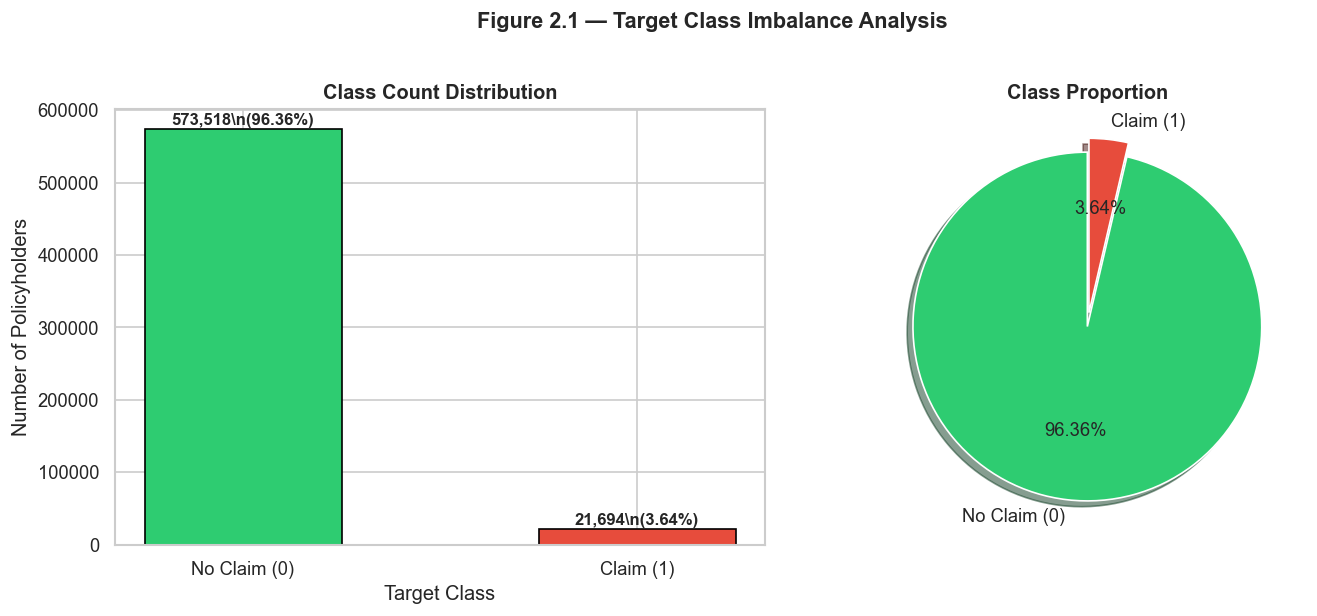

 Saved → data/fig2_1_class_imbalance.png


In [6]:
# ── Visualise class imbalance ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: Count bar chart ─────────────────────────────────────
colors = ['#2ecc71', '#e74c3c']
bars   = axes[0].bar(
    ['No Claim (0)', 'Claim (1)'],
    class_counts.values,
    color=colors,
    edgecolor='black',
    width=0.5
)
axes[0].set_title('Class Count Distribution')
axes[0].set_ylabel('Number of Policyholders')
axes[0].set_xlabel('Target Class')

# Annotate bars with counts and percentages
for bar, count, pct in zip(bars, class_counts.values, class_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2000,
        f'{count:,}\\n({pct}%)',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# ── Right: Pie chart ──────────────────────────────────────────
axes[1].pie(
    class_counts.values,
    labels=['No Claim (0)', 'Claim (1)'],
    colors=colors,
    autopct='%1.2f%%',
    startangle=90,
    explode=(0, 0.08),      # Slightly explode the minority class
    shadow=True
)
axes[1].set_title('Class Proportion')

plt.suptitle(
    'Figure 2.1 — Target Class Imbalance Analysis',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../data/fig2_1_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved → data/fig2_1_class_imbalance.png")


# ── 2.3 FEATURE DISTRIBUTIONS ────────────────────────────────
### 2.3 Feature Distributions by Class

Examining how continuous features are distributed across the two target classes
(claim vs no claim) helps identify which features carry discriminative signal.
Features where the two class distributions visibly differ are likely to be
important predictors in the models trained in Chapter 3.

Porto Seguro's continuous features fall into three groups:
- **ps_ind** — policyholder individual/demographic features
- **ps_reg** — regional features
- **ps_car** — vehicle-related features

In [7]:
# ── Select continuous features for distribution analysis ──────
# Exclude binary (_bin), categorical encoded, and target columns
exclude_suffixes = ('_bin', 'target', 'risk_flag_sum')
cont_cols = [
    col for col in df.columns
    if not any(col.endswith(s) or col == s for s in exclude_suffixes)
    and df[col].dtype in ['float64', 'int64']
    and df[col].nunique() > 10    # Only truly continuous features
][:12]    # Take first 12 for display

print(f" Continuous features selected for distribution analysis: {len(cont_cols)}")
print("   Features:", cont_cols)


 Continuous features selected for distribution analysis: 12
   Features: ['ps_ind_03', 'ps_ind_15', 'ps_reg_02', 'ps_reg_03', 'ps_car_12', 'ps_car_13', 'ps_car_14', 'ps_car_15', 'ps_calc_06', 'ps_calc_08', 'ps_calc_10', 'ps_calc_11']


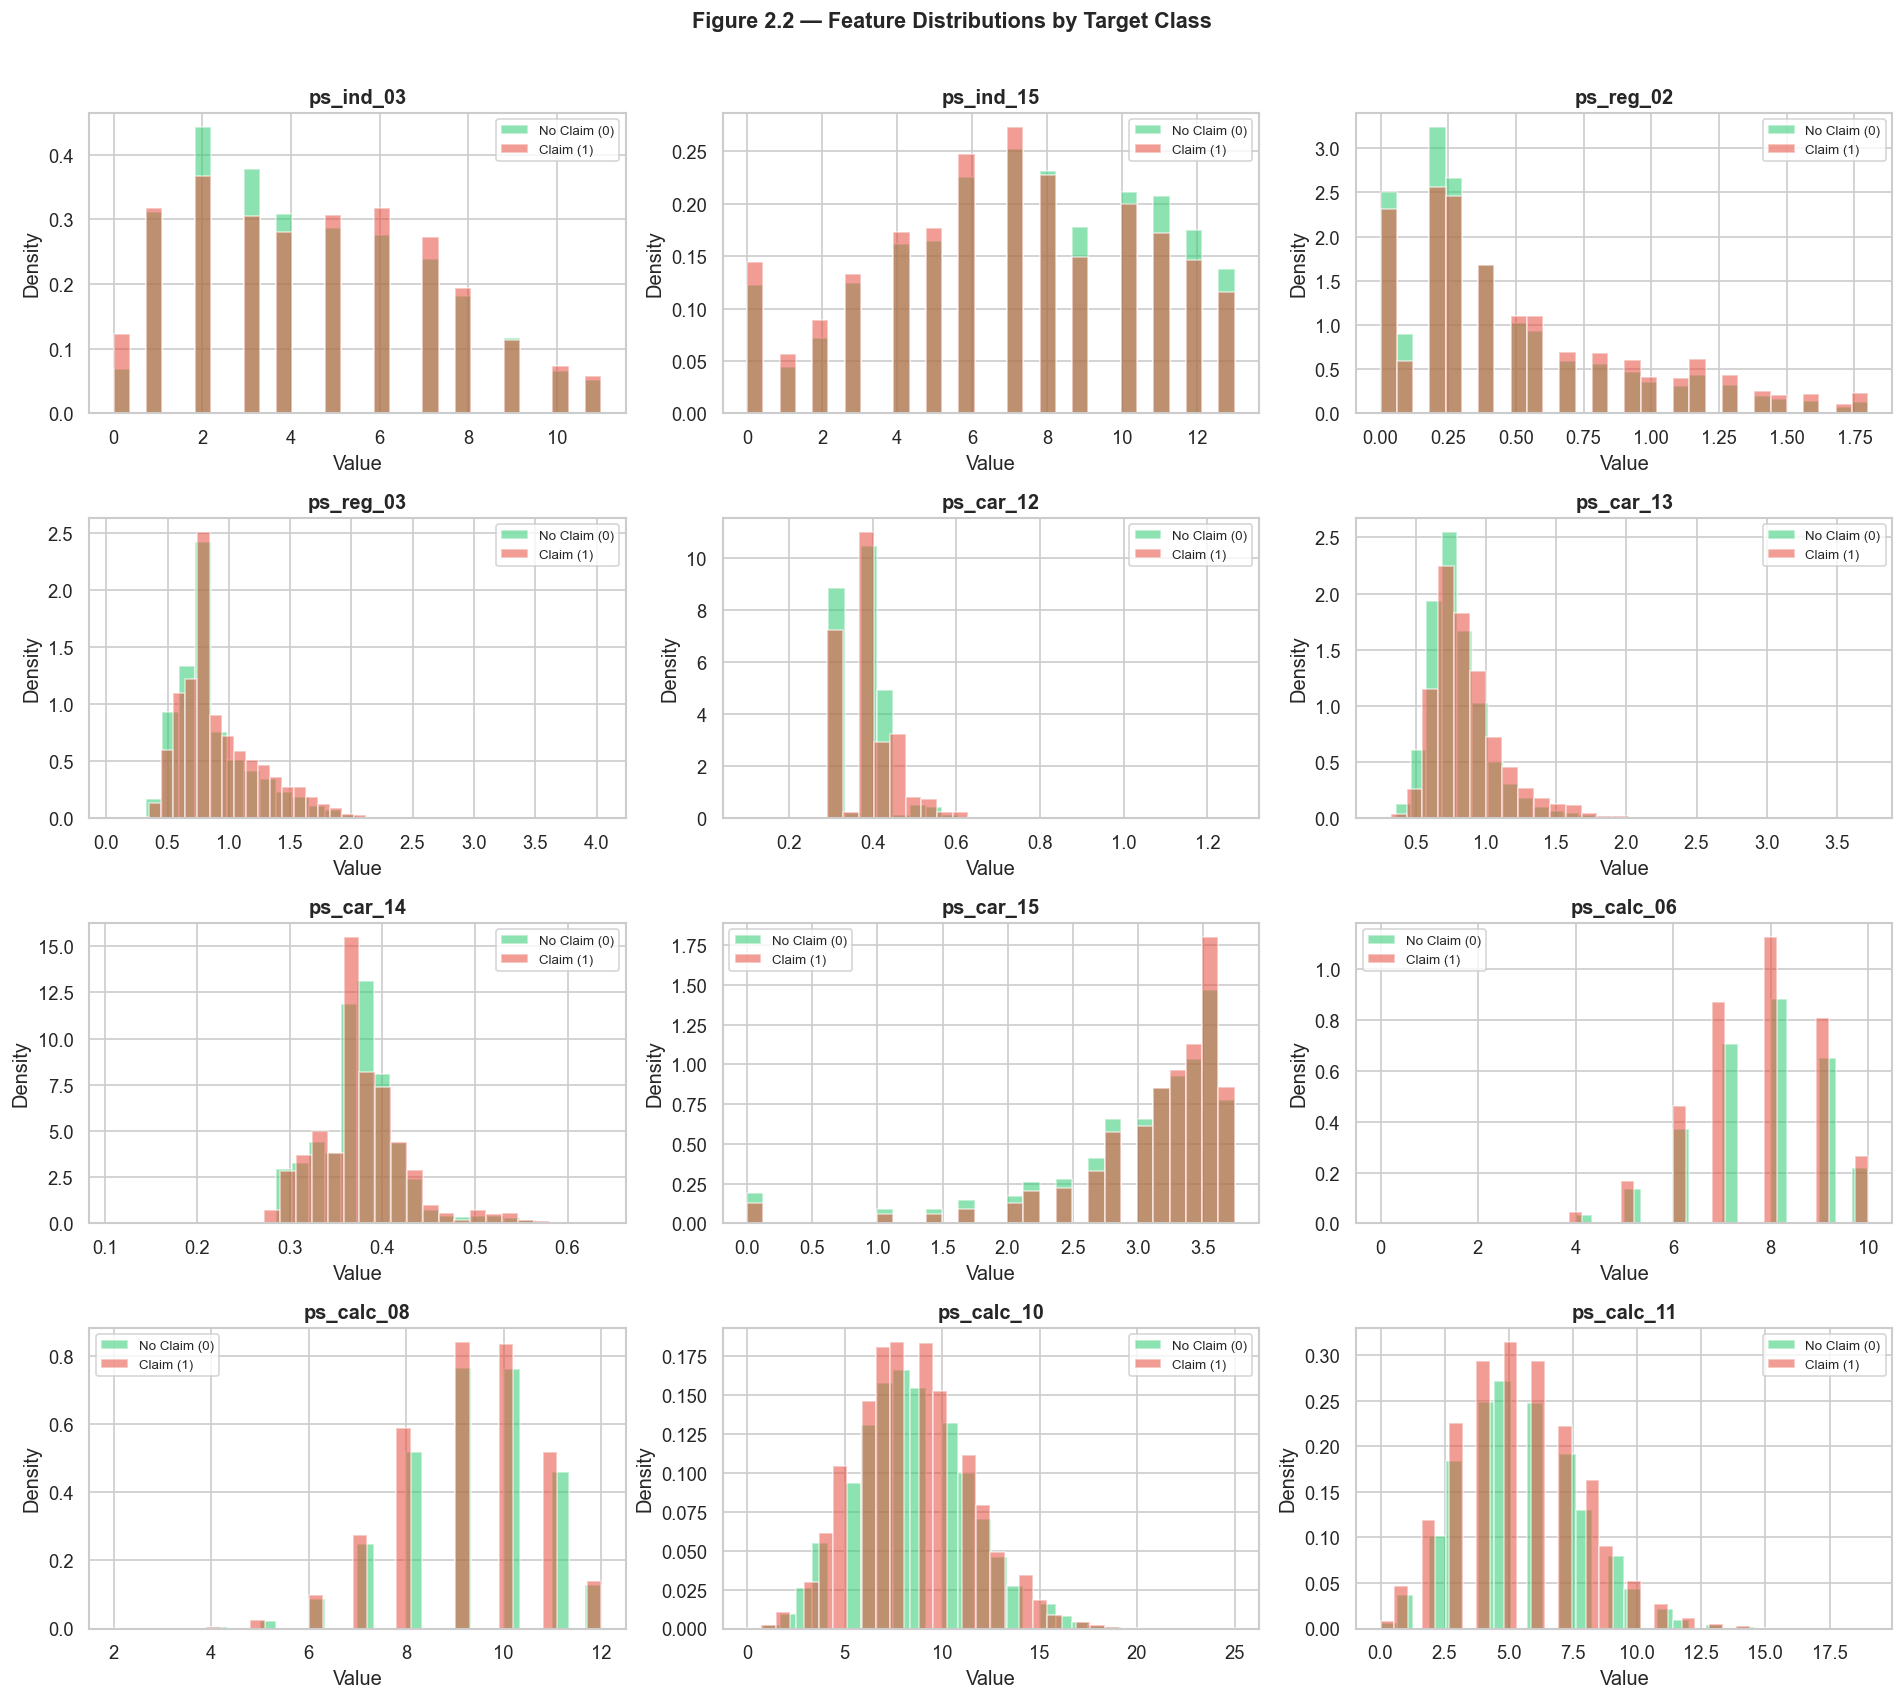

 Saved → data/fig2_2_feature_distributions.png


In [8]:
# ── Distribution plots by class ──────────────────────────────
# Overlapping histograms show where claim vs no-claim
# policyholders differ in each feature

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes      = axes.flatten()

no_claim = df[df['target'] == 0]
claim    = df[df['target'] == 1]

for i, col in enumerate(cont_cols):
    # Plot no-claim distribution
    axes[i].hist(
        no_claim[col].dropna(),
        bins=30, alpha=0.55,
        color='#2ecc71', label='No Claim (0)',
        density=True            # Normalise so both classes are comparable
    )
    # Plot claim distribution
    axes[i].hist(
        claim[col].dropna(),
        bins=30, alpha=0.55,
        color='#e74c3c', label='Claim (1)',
        density=True
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

# Hide any unused subplots
for j in range(len(cont_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Figure 2.2 — Feature Distributions by Target Class',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('../data/fig2_2_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved → data/fig2_2_feature_distributions.png")


In [9]:
# ── Interpretation: features with highest distributional gap ──
# Compute mean difference between claim and no-claim per feature
# Features with large gaps are strongest candidate predictors

dist_gap = pd.DataFrame({
    'No Claim Mean': no_claim[cont_cols].mean(),
    'Claim Mean'   : claim[cont_cols].mean()
})
dist_gap['Absolute Gap'] = (
    dist_gap['Claim Mean'] - dist_gap['No Claim Mean']
).abs()
dist_gap = dist_gap.sort_values('Absolute Gap', ascending=False)

print(" Features with Largest Mean Difference Between Classes:")
print(dist_gap.round(4).to_string())


 Features with Largest Mean Difference Between Classes:
            No Claim Mean  Claim Mean  Absolute Gap
ps_ind_15          7.3148      6.9078        0.4069
ps_ind_03          4.4189      4.5394        0.1204
ps_car_15          3.0620      3.1699        0.1080
ps_reg_02          0.4364      0.5115        0.0751
ps_car_13          0.8109      0.8755        0.0646
ps_reg_03          0.8753      0.9312        0.0560
ps_calc_10         8.4330      8.4494        0.0164
ps_car_12          0.3795      0.3916        0.0121
ps_calc_08         9.2262      9.2184        0.0078
ps_calc_11         5.4412      5.4458        0.0046
ps_car_14          0.3745      0.3771        0.0026
ps_calc_06         7.6894      7.6900        0.0006


# ── 2.4 CORRELATION HEATMAP ──────────────────────────────────
### 2.4 Correlation Heatmap

The correlation heatmap shows the pairwise linear relationships between the
top features most correlated with the target variable. This serves two purposes:

1. **Feature relevance** — features with higher correlation to `target` are
   stronger candidates for the models in Chapter 3
2. **Multicollinearity check** — highly correlated feature pairs can cause
   instability in Logistic Regression coefficients. Identified pairs are
   noted for awareness during model interpretation in Chapter 4.

> **Note:** Correlation measures linear relationships only. Non-linear
> relationships will be captured by Random Forest and XGBoost in Chapter 3
> even if they do not appear strongly here.


In [12]:
# ── Select top 20 features most correlated with target ────────
numeric_cols  = df.select_dtypes(include=[np.number]).columns.tolist()

# Compute absolute correlation with target and take top 20
top_corr_cols = (
    df[numeric_cols]
    .corr()['target']
    .abs()
    .sort_values(ascending=False)
    .head(21)        # 21 = 20 features + target itself
    .index
)

print(f" Top 20 features by absolute correlation with target:")
corr_with_target = df[numeric_cols].corr()['target'].abs()
print(corr_with_target[top_corr_cols].drop('target').sort_values(
    ascending=False).round(4).to_string())


 Top 20 features by absolute correlation with target:
ps_car_13        0.0539
ps_car_12        0.0388
ps_ind_17_bin    0.0371
ps_reg_02        0.0348
ps_ind_07_bin    0.0342
ps_ind_06_bin    0.0340
ps_reg_03        0.0333
ps_ind_16_bin    0.0278
ps_car_15        0.0277
ps_reg_01        0.0229
ps_ind_15        0.0215
ps_ind_01        0.0186
ps_ind_08_bin    0.0131
ps_car_14        0.0112
ps_ind_03        0.0084
ps_ind_09_bin    0.0082
ps_ind_12_bin    0.0078
ps_ind_14        0.0074
ps_ind_18_bin    0.0046
ps_ind_13_bin    0.0025


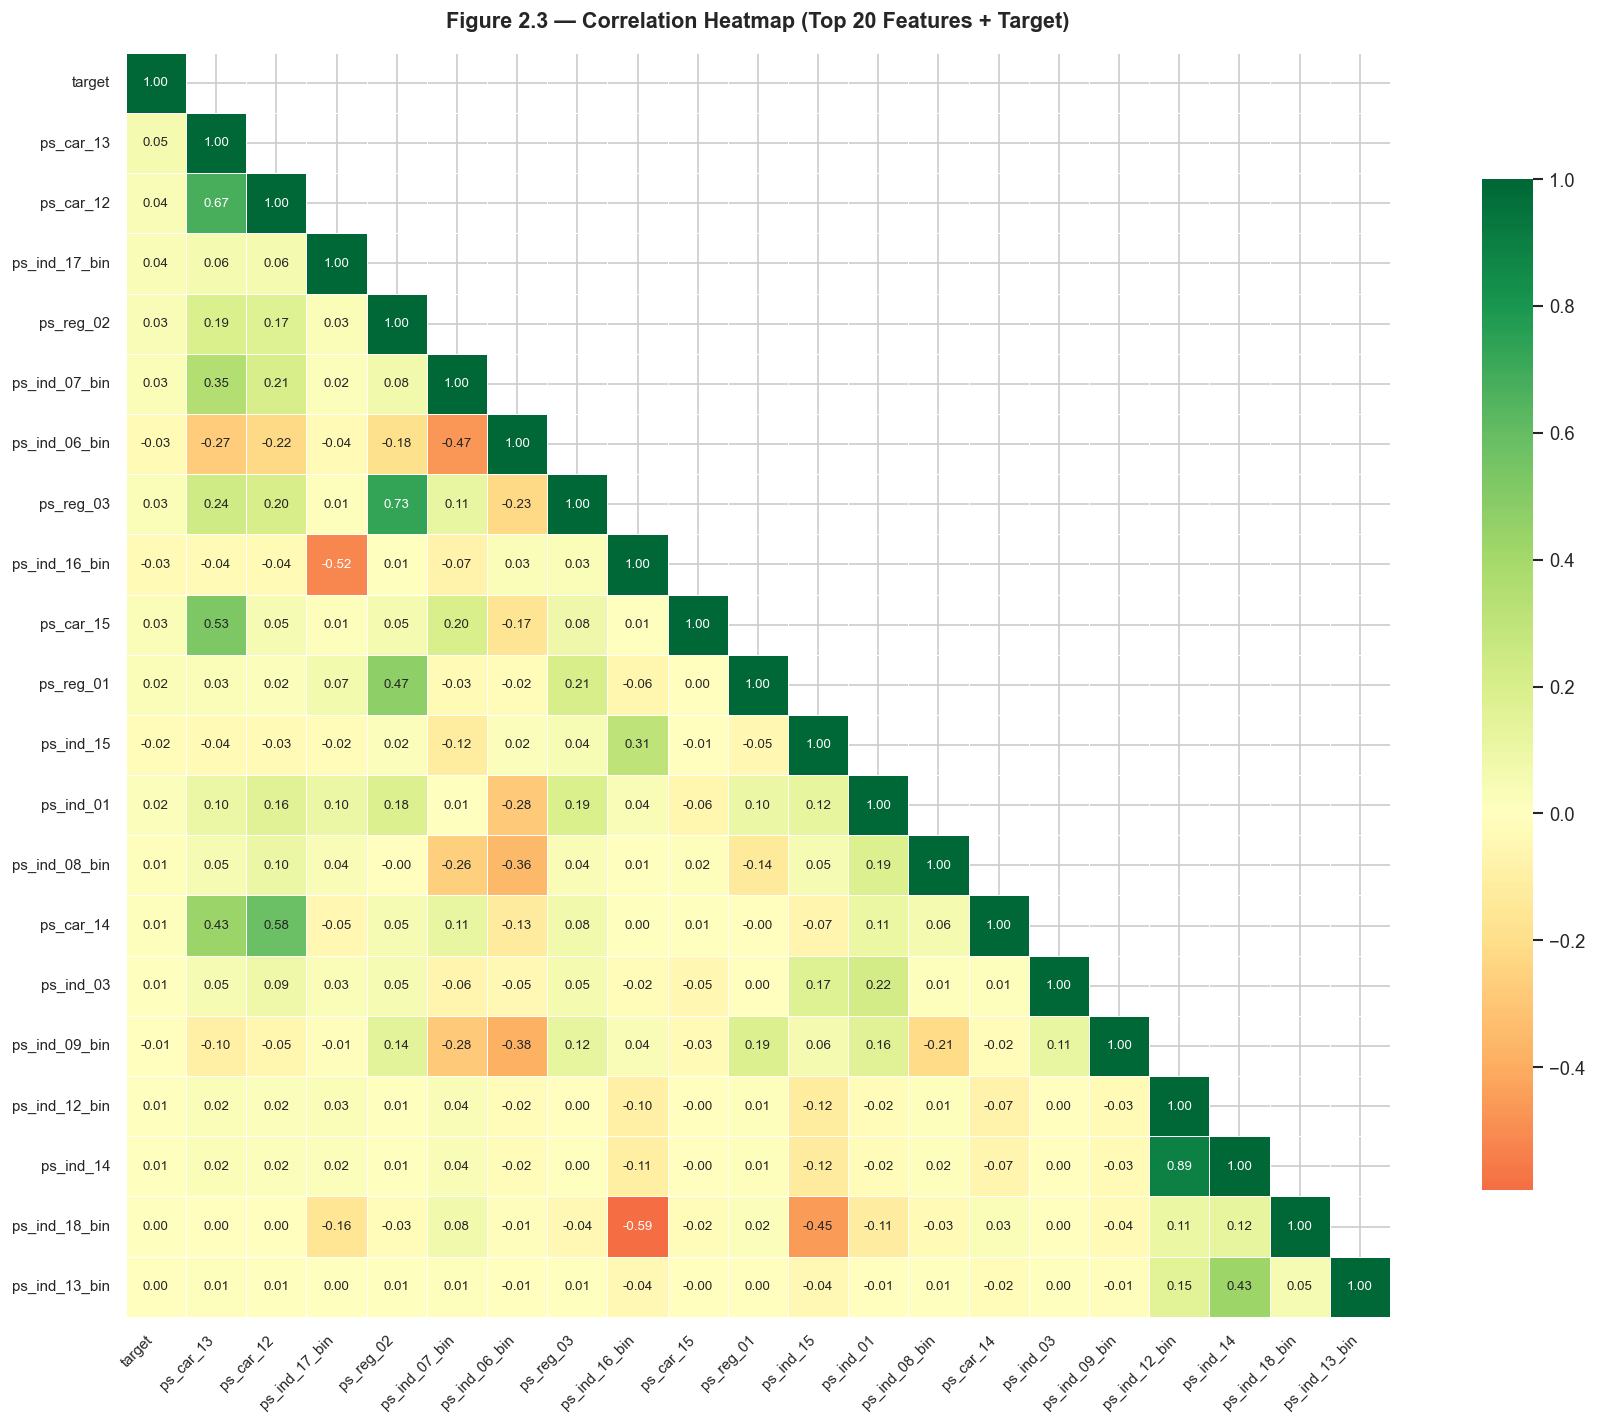

 Saved → data/fig2_3_correlation_heatmap.png


In [13]:
# ── Plot correlation heatmap ──────────────────────────────────
plt.figure(figsize=(16, 12))

corr_matrix = df[top_corr_cols].corr()

# Create mask for upper triangle — avoids redundant information
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 8}
)

plt.title(
    'Figure 2.3 — Correlation Heatmap (Top 20 Features + Target)',
    fontsize=13, fontweight='bold', pad=15
)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('../data/fig2_3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved → data/fig2_3_correlation_heatmap.png")


In [15]:
# ── Flag highly correlated feature pairs ─────────────────────
# Pairs with |correlation| > 0.7 may cause multicollinearity
# in Logistic Regression — flagged here for awareness

threshold    = 0.7
corr_matrix  = df[top_corr_cols].drop(columns=['target']).corr().abs()
upper        = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] > threshold
]

if high_corr_pairs:
    print(f"  Feature pairs with |correlation| > {threshold}:")
    for f1, f2, corr in sorted(high_corr_pairs, key=lambda x: -x[2]):
        print(f"   {f1:<30} ↔  {f2:<30}  r = {corr:.3f}")
    print("\\n   Note: These pairs may affect Logistic Regression")
    print("   coefficient stability. Tree models are unaffected.")
else:
    print(f" No feature pairs exceed correlation threshold of {threshold}.")


  Feature pairs with |correlation| > 0.7:
   ps_ind_14                      ↔  ps_ind_12_bin                   r = 0.890
   ps_reg_03                      ↔  ps_reg_02                       r = 0.728
\n   Note: These pairs may affect Logistic Regression
   coefficient stability. Tree models are unaffected.


# ── 2.5 OUTLIER DETECTION ────────────────────────────────────
### 2.5 Outlier Detection

Outliers are examined using boxplots on the continuous features. In the context
of insurance data, extreme values are not necessarily errors, a very high vehicle
value or an unusually long driving history may be genuine and meaningful signals.

The purpose here is not to remove outliers but to:
1. Confirm that median imputation in Chapter 1 was appropriate
2. Understand the spread of key features before modelling
3. Note any extreme values that may disproportionately influence
   Logistic Regression (tree models are robust to outliers)


In [16]:
# ── Select features for outlier analysis ─────────────────────
# Focus on ps_reg and ps_car continuous features
# as these are the most actuarially relevant
outlier_cols = [
    col for col in df.columns
    if ('ps_reg' in col or 'ps_car' in col)
    and not col.endswith('_bin')
    and not col.endswith('_cat')
    and df[col].dtype in ['float64', 'int64']
    and df[col].nunique() > 10
][:8]

print(f" Features selected for outlier analysis: {len(outlier_cols)}")
print("   Features:", outlier_cols)


 Features selected for outlier analysis: 6
   Features: ['ps_reg_02', 'ps_reg_03', 'ps_car_12', 'ps_car_13', 'ps_car_14', 'ps_car_15']


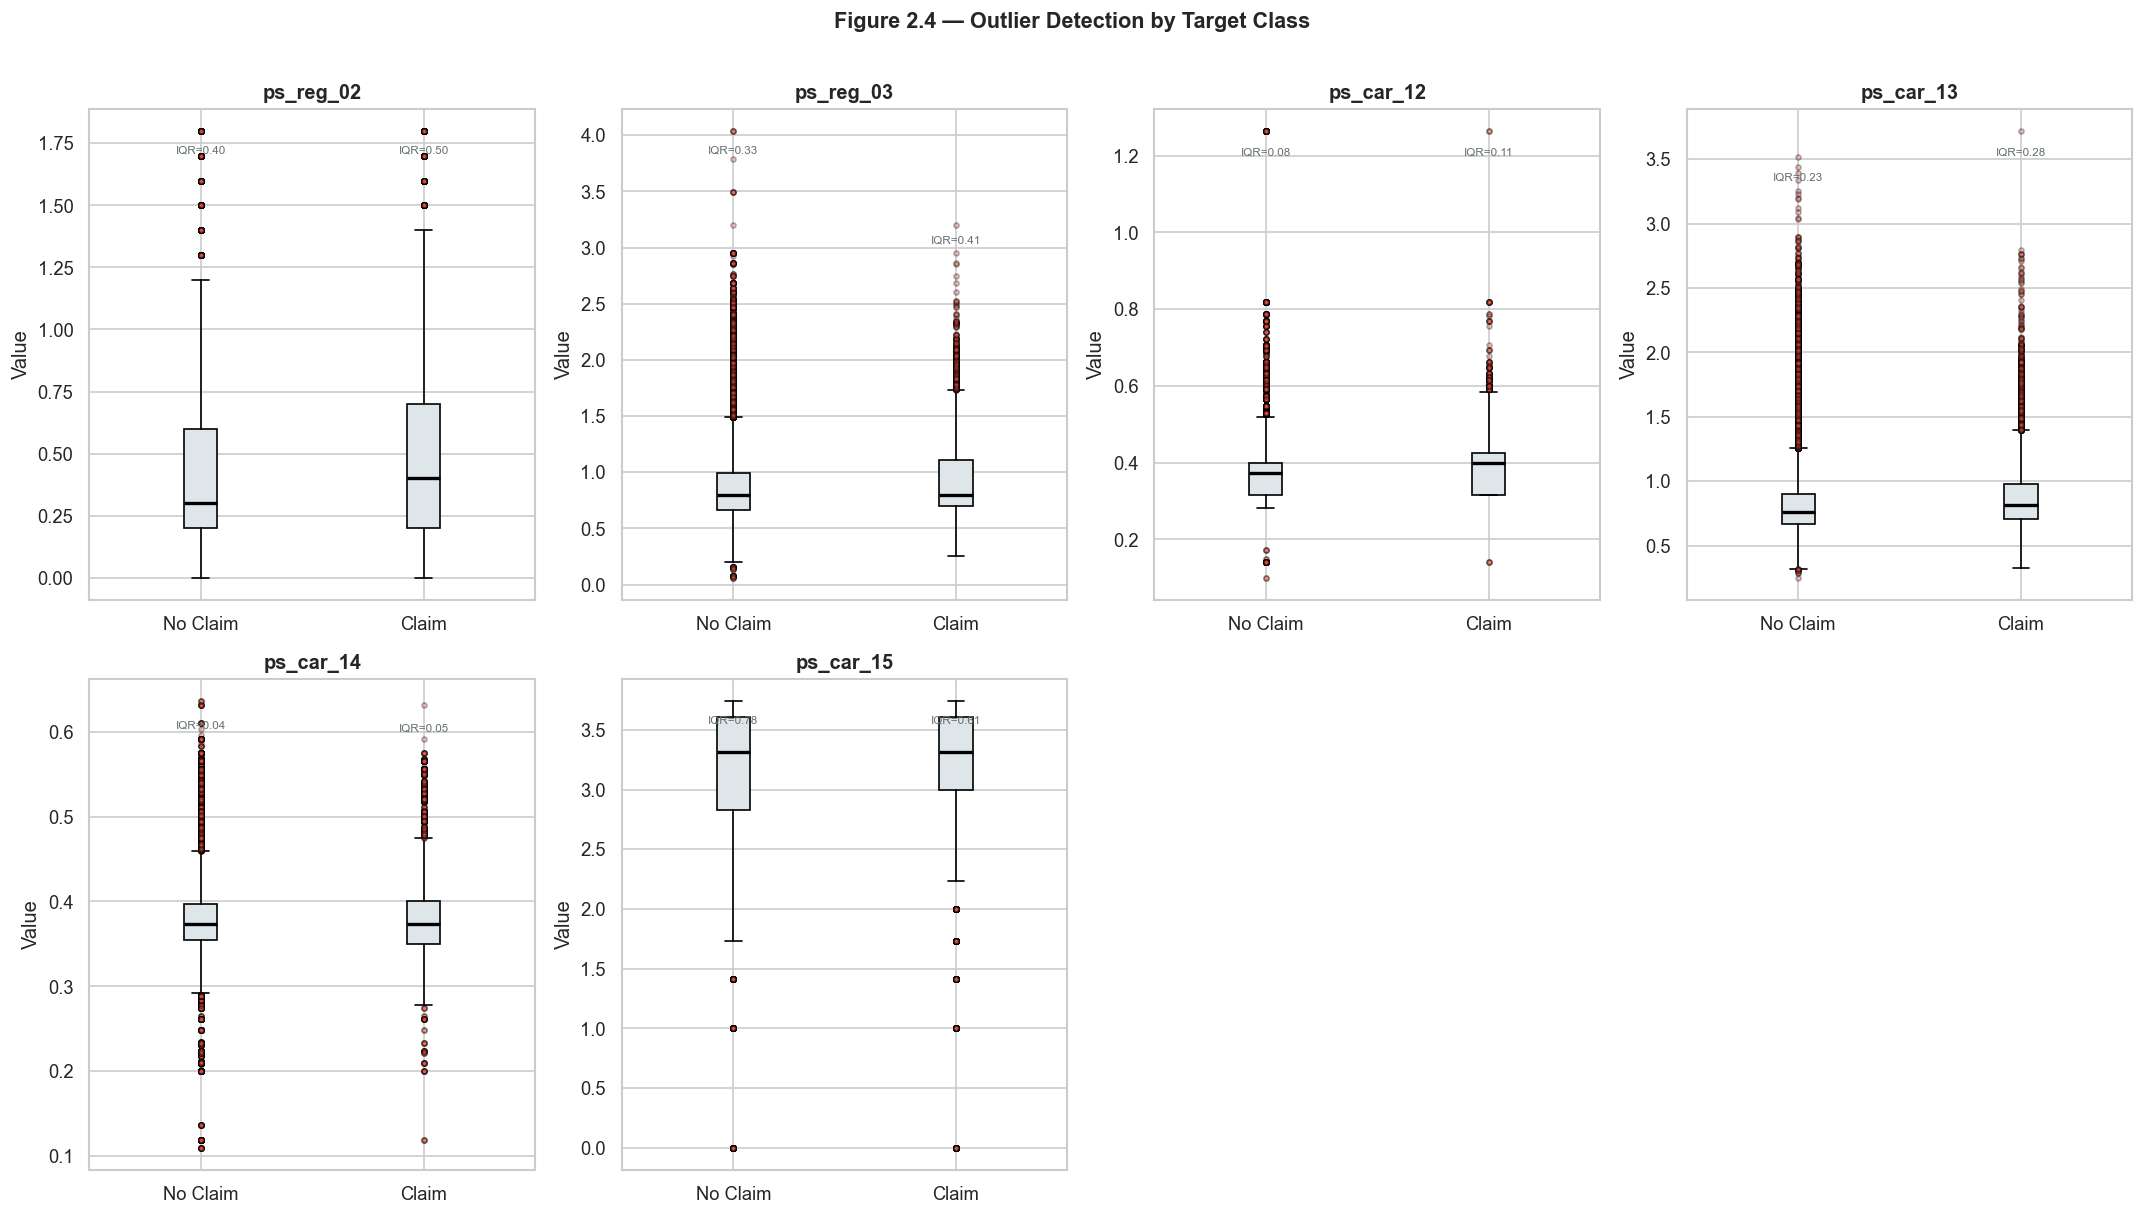

 Saved → data/fig2_4_outlier_boxplots.png


In [17]:
# ── Boxplots split by target class ───────────────────────────
# Splitting by class reveals whether outliers are concentrated
# in claimants or non-claimants — an actuarially useful insight

n_cols  = 4
n_rows  = -(-len(outlier_cols) // n_cols)    # Ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes      = axes.flatten()

for i, col in enumerate(outlier_cols):
    # Prepare data per class
    data_0 = df[df['target'] == 0][col].dropna()
    data_1 = df[df['target'] == 1][col].dropna()

    axes[i].boxplot(
        [data_0, data_1],
        labels=['No Claim', 'Claim'],
        patch_artist=True,
        boxprops=dict(facecolor='#dfe6e9'),
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(
            marker='o', markerfacecolor='#e74c3c',
            markersize=3, alpha=0.3
        )
    )
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

    # Annotate with IQR and median
    for j, data in enumerate([data_0, data_1]):
        q1  = data.quantile(0.25)
        q3  = data.quantile(0.75)
        iqr = q3 - q1
        axes[i].text(
            j + 1, data.max() * 0.95,
            f'IQR={iqr:.2f}',
            ha='center', fontsize=7, color='#636e72'
        )

# Hide unused subplots
for j in range(len(outlier_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Figure 2.4 — Outlier Detection by Target Class',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('../data/fig2_4_outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved → data/fig2_4_outlier_boxplots.png")


In [18]:
# ── Quantify outliers using IQR method ───────────────────────
# An outlier is defined as a value beyond Q1 - 1.5*IQR
# or Q3 + 1.5*IQR — the standard Tukey fence method

print(" Outlier Count per Feature (IQR method):")
print(f"{'Feature':<30} {'Outliers':>10} {'% of column':>12}")
print("-" * 55)

for col in outlier_cols:
    q1      = df[col].quantile(0.25)
    q3      = df[col].quantile(0.75)
    iqr     = q3 - q1
    lower   = q1 - 1.5 * iqr
    upper   = q3 + 1.5 * iqr
    n_out   = ((df[col] < lower) | (df[col] > upper)).sum()
    pct_out = n_out / len(df) * 100
    print(f"{col:<30} {n_out:>10,} {pct_out:>11.2f}%")

print("\\n   Note: Outliers retained — median imputation in Chapter 1")
print("   already handles extreme values appropriately.")
print("   Tree-based models (RF, XGBoost) are robust to outliers.")
print("   Logistic Regression uses scaled features which reduce impact.")


 Outlier Count per Feature (IQR method):
Feature                          Outliers  % of column
-------------------------------------------------------
ps_reg_02                          36,793        6.18%
ps_reg_03                          35,514        5.97%
ps_car_12                          15,355        2.58%
ps_car_13                          26,913        4.52%
ps_car_14                          30,420        5.11%
ps_car_15                          27,409        4.60%
\n   Note: Outliers retained — median imputation in Chapter 1
   already handles extreme values appropriately.
   Tree-based models (RF, XGBoost) are robust to outliers.
   Logistic Regression uses scaled features which reduce impact.


# ── 2.6 EDA SUMMARY ──────────────────────────────────────────
### 2.6 EDA Summary and Modelling Implications

This section summarises the key findings from the exploratory analysis and
documents how each finding informs the modelling decisions in Chapter 3.


In [19]:
# ── Print structured EDA summary ─────────────────────────────
print("=" * 60)
print("  CHAPTER 2 COMPLETE — EDA SUMMARY")
print("=" * 60)

print("""
FINDING 1 — Class Imbalance
  The dataset is heavily imbalanced at approximately 26:1
  (no claim vs claim). Standard accuracy metrics will be
  misleading. AUC-ROC and F1-score are used for evaluation
  in Chapter 4. class_weight='balanced' is applied to all
  models in Chapter 3.

FINDING 2 — Feature Distributions
  Several ps_car and ps_reg features show distributional
  differences between claimants and non-claimants, confirming
  they carry predictive signal. This supports their inclusion
  in all three models.

FINDING 3 — Correlations
  No single feature shows strong linear correlation with the
  target. This suggests the relationship between features and
  claim probability is predominantly non-linear — supporting
  the use of Random Forest and XGBoost alongside the linear
  Logistic Regression baseline.

FINDING 4 — Outliers
  Outliers are present in vehicle and regional features but
  are consistent with real-world insurance data. They have
  been retained. Median imputation in Chapter 1 ensures
  missing values were not confused with genuine extremes.
  Tree-based models handle these naturally.
""")

print("  Proceed to Chapter 3 — Model Training")


  CHAPTER 2 COMPLETE — EDA SUMMARY

FINDING 1 — Class Imbalance
  The dataset is heavily imbalanced at approximately 26:1
  (no claim vs claim). Standard accuracy metrics will be
  misleading. AUC-ROC and F1-score are used for evaluation
  in Chapter 4. class_weight='balanced' is applied to all
  models in Chapter 3.

FINDING 2 — Feature Distributions
  Several ps_car and ps_reg features show distributional
  differences between claimants and non-claimants, confirming
  they carry predictive signal. This supports their inclusion
  in all three models.

FINDING 3 — Correlations
  No single feature shows strong linear correlation with the
  target. This suggests the relationship between features and
  claim probability is predominantly non-linear — supporting
  the use of Random Forest and XGBoost alongside the linear
  Logistic Regression baseline.

FINDING 4 — Outliers
  Outliers are present in vehicle and regional features but
  are consistent with real-world insurance data. They have